In [1]:
from mapc_cmab.agents.hierarchical_dqn  import HierarchicalMapcDQNAgent 
from mapc_cmab.agents.mapc_cmab_agent_factory import MapcDQNAgentFactory
from mapc_cmab.envs.scenario_impl import small_office_scenario 
import jax 
import jax.numpy as jnp 
from tqdm import tqdm 
import numpy as np 

In [24]:
d_ap = 10
d_sta = 4
scenario = small_office_scenario(d_ap=d_ap, d_sta=d_sta)
n_aps = len(scenario.associations.keys())
n_nodes = n_aps + len(scenario.associations.keys()) * len(scenario.associations[0])

In [25]:
print(n_nodes)

20


In [26]:
link_ap_sta_matrix = np.zeros((n_nodes, n_nodes), dtype=np.float64)

link_ap_sta_matrix[0, 4] = 1

power = np.zeros((3, n_nodes), dtype=np.int32)
power[:, 0] = 3

link_ap_sta = (
    np.repeat(link_ap_sta_matrix[None, :, :], 3, axis=0),
    power,
)

In [27]:
print(np.where(link_ap_sta[1] >0 ))

(array([0, 1, 2]), array([0, 0, 0]))


In [28]:
key = jax.random.PRNGKey(42)
np.int32(3)

np.int32(3)

In [29]:
len(link_ap_sta[1].shape)

2

In [31]:
n_steps = 5000
n_reps = 5

throughputs = np.zeros(shape=(n_reps, n_steps))

for run_number in tqdm(range(n_reps), desc=f"runs"):
    key, run_key = jax.random.split(key)
    throughputs_step = np.zeros(shape=(n_steps, ))
    for step in tqdm(range(1, n_steps), desc=f"run_number{run_number}", leave=True):
        run_key, step_key = jax.random.split(run_key)
        reward, _ = scenario(key=step_key, link_ap_sta=link_ap_sta)
        throughputs_step[step] = reward

    throughputs[run_number] = throughputs_step


runs: 100%|██████████| 5/5 [00:11<00:00,  2.23s/it]


In [32]:
from mapc_cmab.plots.throughput_analysis.throughput_ci import analyze_and_plot_throughputs

Figure saved to:
results\single_ap_d_sta_4.png
Statistics saved to:
results\single_ap_d_sta_4.npz


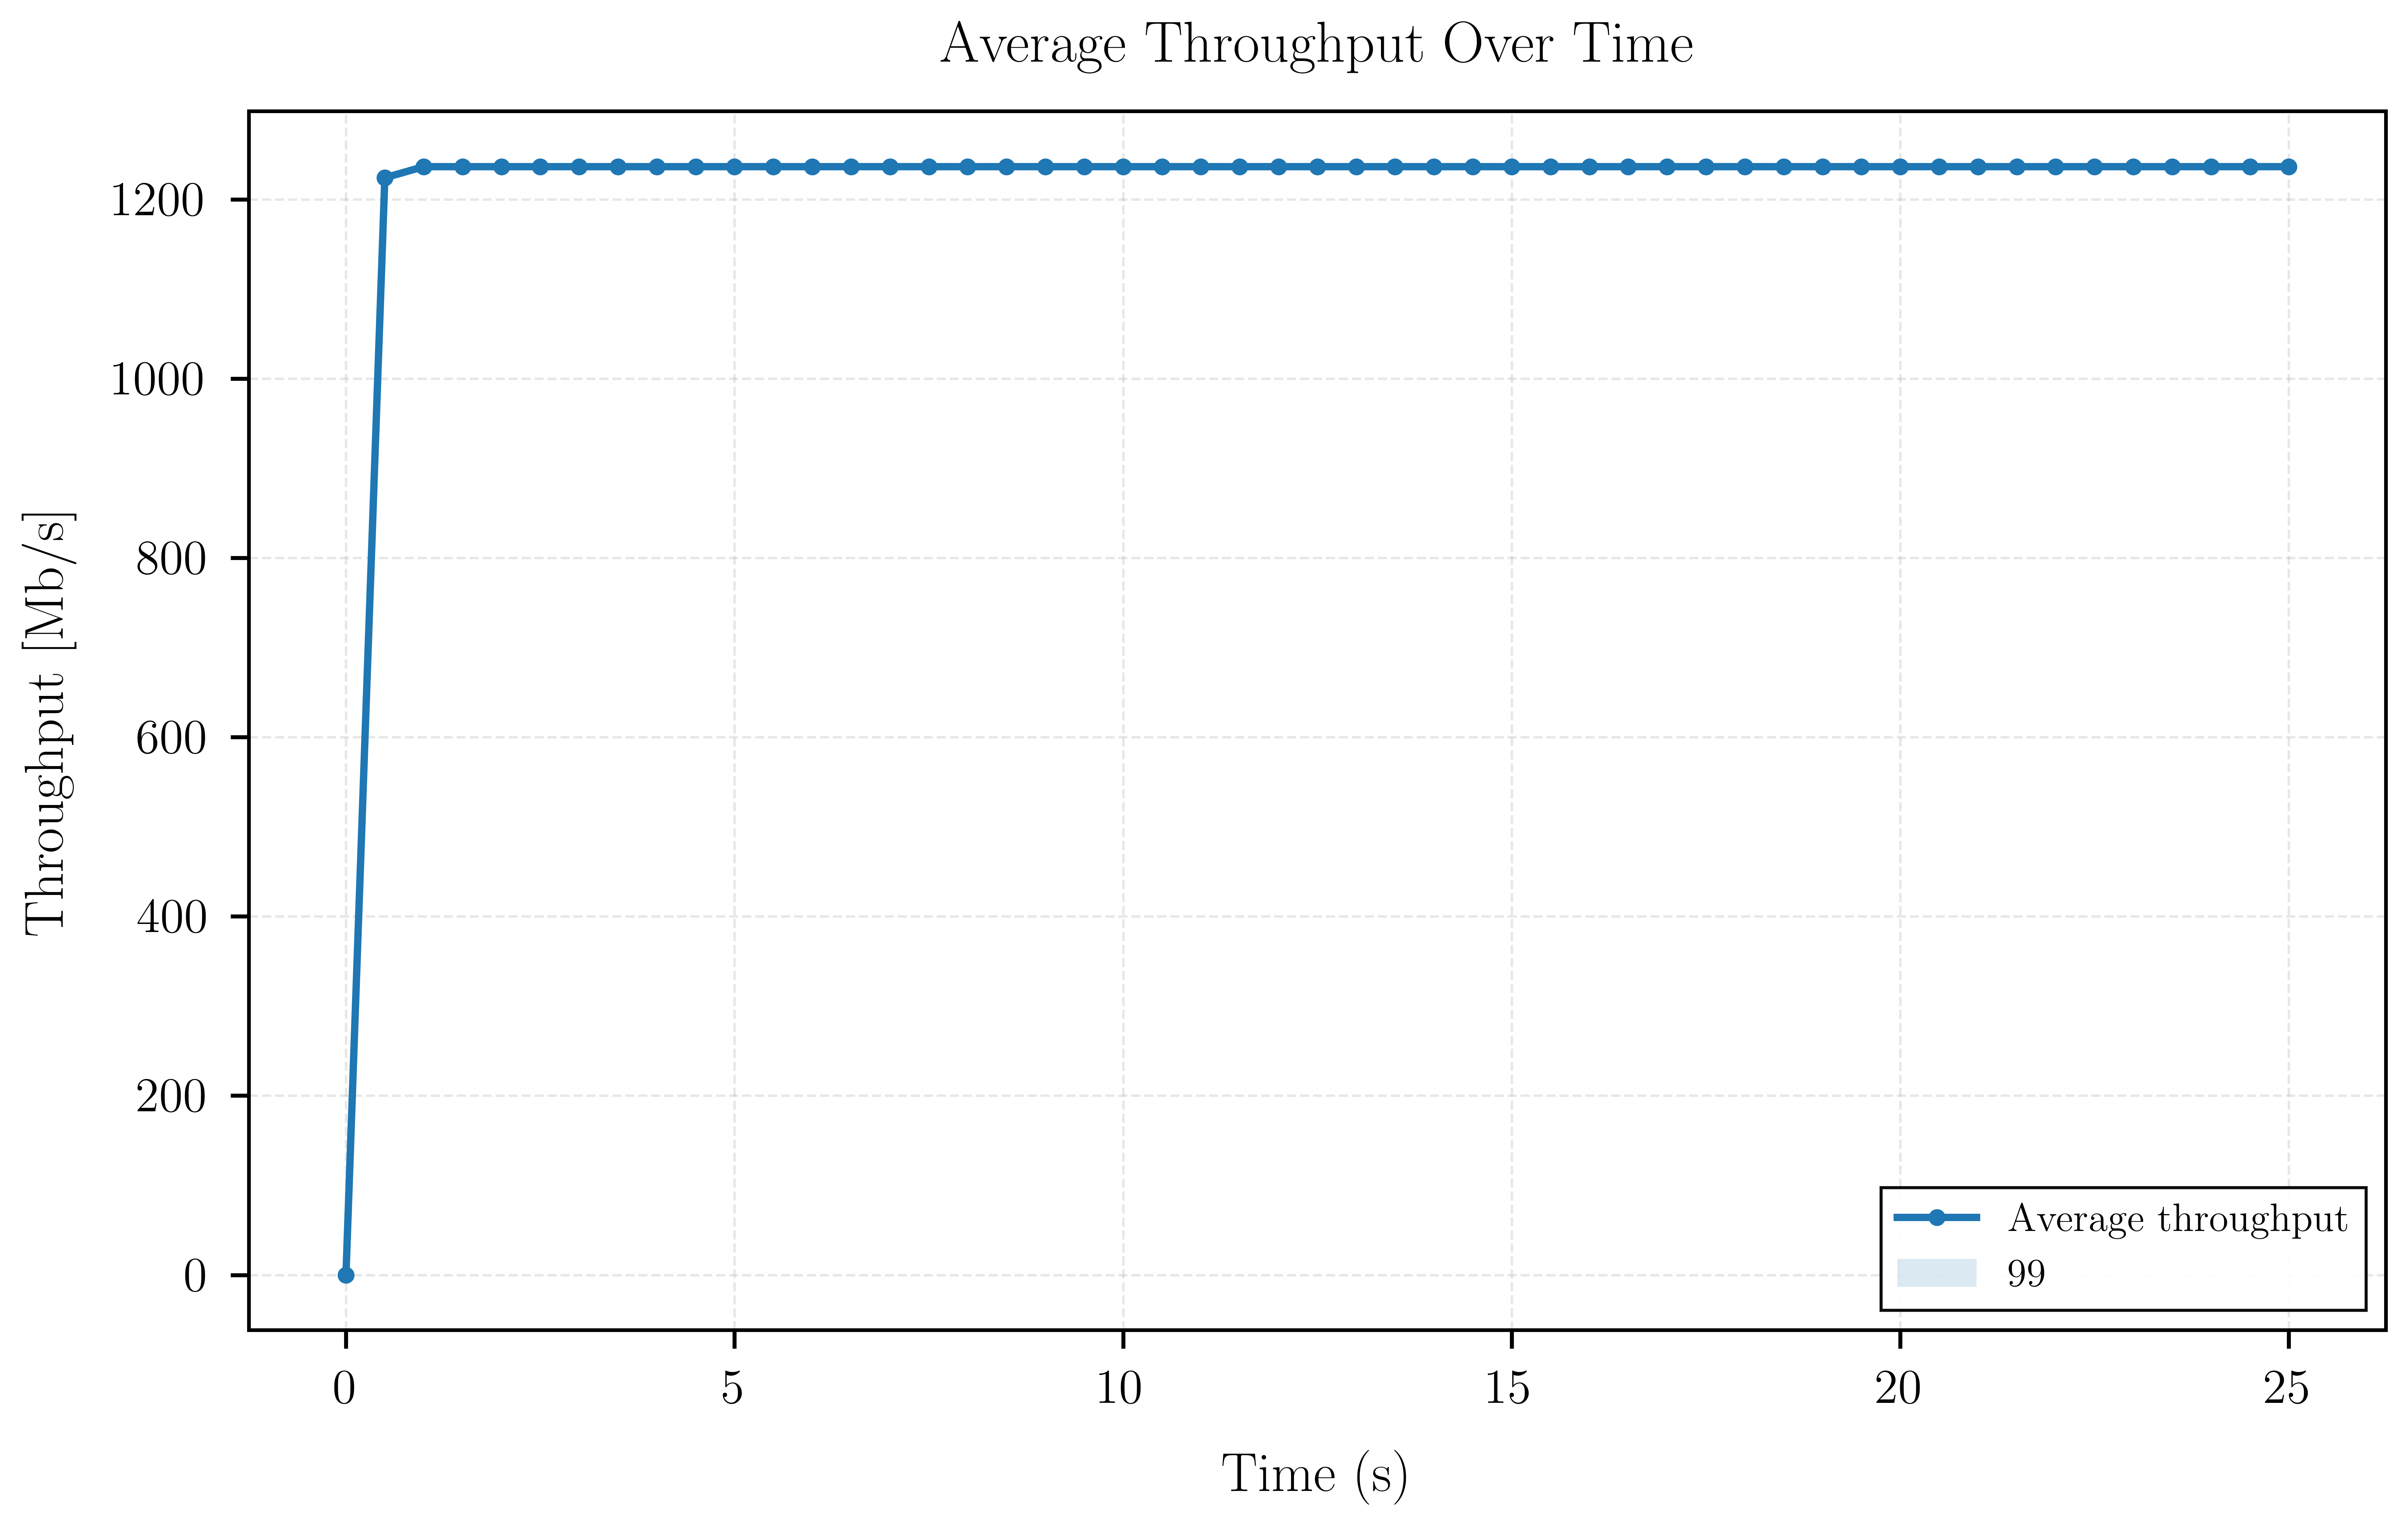

{'windowed_throughputs': array([[1223.96061401, 1236.32385254, 1236.32385254, 1236.32385254,
         1236.32385254, 1236.32385254, 1236.32385254, 1236.32385254,
         1236.32385254, 1236.32385254, 1236.32385254, 1236.28008789,
         1236.32385254, 1236.32385254, 1236.32385254, 1236.28008789,
         1236.32385254, 1236.32385254, 1236.32385254, 1236.32385254,
         1236.32385254, 1236.32385254, 1236.32385254, 1236.32385254,
         1236.32385254, 1236.32385254, 1236.32385254, 1236.32385254,
         1236.32385254, 1236.32385254, 1236.32385254, 1236.32385254,
         1236.32385254, 1236.32385254, 1236.32385254, 1236.32385254,
         1236.32385254, 1236.32385254, 1236.32385254, 1236.32385254,
         1236.32385254, 1236.32385254, 1236.32385254, 1236.32385254,
         1236.32385254, 1236.32385254, 1236.32385254, 1236.32385254,
         1236.32385254, 1236.32385254],
        [1223.96061401, 1236.32385254, 1236.32385254, 1236.32385254,
         1236.32385254, 1236.32385254, 

In [33]:
analyze_and_plot_throughputs(throughputs, filename=f"single_ap_d_sta_{d_sta}")